In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE

sys.path.insert(0, "../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

import warnings
warnings.filterwarnings("ignore")

In [2]:
cmacedonia_path = f'../data/CMacedonia/GR_CMacedonia_WNV_Dataset_2010_2022.csv'
thessaly_path = f'../data/Thessaly/GR_Thessaly_WNV_Dataset_2010_2022.csv'
attica_path = f'../data/Attica/GR_Attica_WNV_Dataset_2010_2022.csv'

In [3]:
dataset1 = read_data(cmacedonia_path)
dataset2 = read_data(thessaly_path)
dataset3 = read_data(attica_path)

In [4]:
data = pd.concat([dataset1, dataset2, dataset3])

In [5]:
data

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,478.8,38293.0,86.8,46.40326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.701364,12.274545,7.128182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.201406,0.201406,0.201406,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071,31,99,36,99.0,30,99,12,12,1,6,7,2,0,12,0,0
1,22.07722,41.01522,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,985.8,24924.0,28.0,46.57952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.994259,10.090000,5.898519,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,0.096034,0.096034,0.096034,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432,31,94,36,95.0,30,94,12,12,3,5,8,2,0,11,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,15,0,0
3,23.95900,40.91196,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,411.8,7169.0,22.3,47.41120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.262667,12.496667,8.028667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,0.036767,0.036767,0.036767,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784,31,93,36,93.0,30,93,12,12,3,5,8,2,0,4,0,0
4,23.69747,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.979530,5.000000e-01,0.866025,-2.449294e-16,1.00000,747.0,16994.0,24.5,46.92004,0.187515,0.122263,-0.006515,-0.122263,0.155857,0.132800,0.032298,-0.132800,0.018865,0.020253,0.039362,0.020253,11.778056,15.171111,8.385000,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,1.425578,1.425578,1.425578,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,13,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20704,23.77628,38.01477,2022-12-16,αττικης,φιλοθεης ψυχικου,16,12,50,2022,-0.101168,-0.994869,-2.449294e-16,1.000000,-3.482016e-01,0.93742,6.1,27400.0,4421.0,44.83787,0.311134,0.172093,-0.267181,-0.172093,0.273675,0.155426,-0.244386,-0.155426,0.032497,0.021730,0.027345,0.021730,13.190000,14.610000,11.770000,9.384667,5.348750,14.602727,6.377143,16.025556,5.006250,25.226471,13.147143,64.381842,66.835793,878.533587,11493.394440,1249.231013,1,170.390702,196.747784,173.755606,0.0,1.000000,22,89,9,99.0,20,89,13,13,10,8,9,2,0,4,19,0
20705,23.67294,38.10558,2022-12-16,αττικης,φυλης,16,12,50,

In [6]:
cases = data.query('case == 1')

print(f'Months:  {cases.month.drop_duplicates().sort_values().values.tolist()}')
print(f'Years:  {cases.year.drop_duplicates().sort_values().values.tolist()}')

Months:  [5, 6, 7, 8, 9, 10, 11]
Years:  [2010, 2011, 2012, 2013, 2014, 2018, 2019, 2020, 2021, 2022]


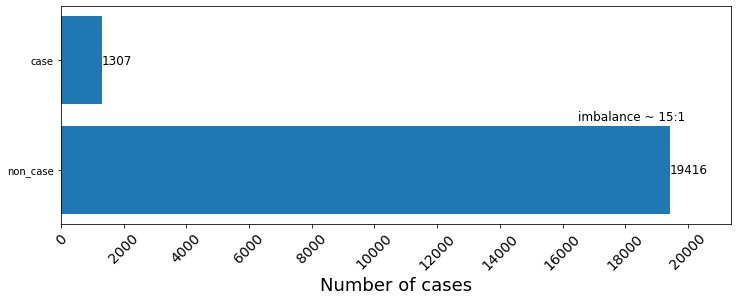

In [7]:
plot_imbalance(data.query('month >= 5 & month <= 10'))

In [8]:
dataset = data.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2010-05-01,κεντρικης μακεδονιας,αλεξανδρειας,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,478.8,38293.0,86.8,46.40326,0.277884,0.135286,-0.119594,-0.135286,0.289617,0.144593,-0.120979,-0.144593,0.033875,0.026132,0.013320,0.026132,23.797273,34.776364,12.818182,7.312171,4.246515,10.352999,2.171842,18.828855,4.429441,27.911638,9.435484,0.849520,45.860931,513.316999,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071,31,99,36,99.0,30,99,12,12,1,6,7,2,0,1,84,0
1,22.07722,41.01522,2010-05-01,κεντρικης μακεδονιας,αλμωπιας,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,985.8,24924.0,28.0,46.57952,0.452498,0.135039,-0.276990,-0.135039,0.445984,0.140292,-0.264097,-0.140292,0.048772,0.040999,0.041759,0.040999,16.598704,23.051111,10.146296,5.181182,0.897706,6.029711,0.652317,14.582631,2.214703,20.480504,6.770962,13.010832,79.418586,556.232491,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432,31,94,36,95.0,30,94,12,12,3,5,8,2,0,17,222,0
2,22.89198,40.65603,2010-05-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,9.8,49674.0,5319.1,46.65786,0.170802,0.062868,-0.101038,-0.062868,0.166419,0.052195,-0.123815,-0.052195,0.085079,0.060522,0.023502,0.060522,22.320000,30.450000,14.190000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,3.478170,46.557858,498.499728,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,6,133,0
3,23.95900,40.91196,2010-05-01,κεντρικης μακεδονιας,αμφιπολης,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,411.8,7169.0,22.3,47.41120,0.520024,0.242873,-0.253985,-0.242873,0.518081,0.244385,-0.249705,-0.244385,0.043771,0.051783,0.033458,0.051783,18.250000,25.719333,10.780667,7.915689,3.881189,10.345446,2.526576,15.461649,3.791537,21.045957,8.670280,4.135710,17.931808,570.517413,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784,31,93,36,93.0,30,93,12,12,3,5,8,2,0,26,88,0
4,23.69747,40.49593,2010-05-01,κεντρικης μακεδονιας,αριστοτελη,1,5,17,2010,0.201299,0.97953,0.5,-0.866025,0.902798,-0.430065,747.0,16994.0,24.5,46.92004,0.609696,0.317190,-0.243338,-0.317190,0.612239,0.315245,-0.246933,-0.315245,0.039368,0.041644,0.042532,0.041644,16.137222,21.571111,10.703333,9.406631,5.692600,8.648461,3.348754,15.271551,4.125444,19.126880,8.177886,9.678622,35.371020,502.368716,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,36,138,0


In [9]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment',
       'lc_prop2', 'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment',
       'lc_type1', 'lc_type2', 'lc_type3', 'lc

In [10]:
print(f'LAU1 Units: {dataset.lau1.unique().shape[0]}')

LAU1 Units: 129


In [11]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,1453,259,1712,8.26%
1,2011,1480,91,1571,7.58%
2,2012,1507,65,1572,7.59%
3,2013,1503,56,1559,7.52%
4,2014,1546,2,1548,7.47%
5,2015,1548,0,1548,7.47%
6,2016,1548,0,1548,7.47%
7,2017,1548,0,1548,7.47%
8,2018,1389,279,1668,8.05%
9,2019,1466,130,1596,7.70%


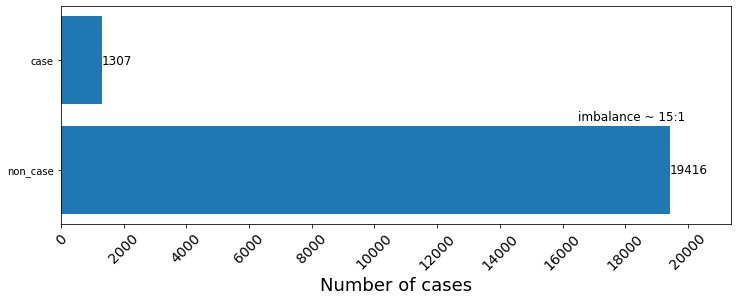

In [12]:
plot_imbalance(dataset)

In [13]:
majority_class = 0
near_u = 0.2
smote = 0.5
scaler = 'minmax'
weight_multiplier = 1
years_to_remove = [2014, 2015, 2016, 2017]
#years_to_remove = []
features_to_remove = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 
                      'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 
                      'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5','lw', 'qc',]
#features_to_remove = []

In [14]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                        + features_to_remove).columns

print(feature_names)

Index(['month_sin', 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
       'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')


In [15]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler_key=scaler, majority_class=majority_class, exclude_features=features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:7 || ##
Year: 2011 || w0:1, w1:6 || ##
Year: 2012 || w0:1, w1:6 || ##
Year: 2013 || w0:1, w1:6 || ##
Year: 2014 || w0:1, w1:6 || ##
Year: 2015 || w0:1, w1:6 || ##
Year: 2016 || w0:1, w1:6 || ##
Year: 2017 || w0:1, w1:6 || ##
Year: 2018 || w0:1, w1:7 || ##
Year: 2019 || w0:1, w1:6 || ##
Year: 2020 || w0:1, w1:6 || ##
Year: 2021 || w0:1, w1:5 || ##
Year: 2022 || w0:1, w1:7 || ##


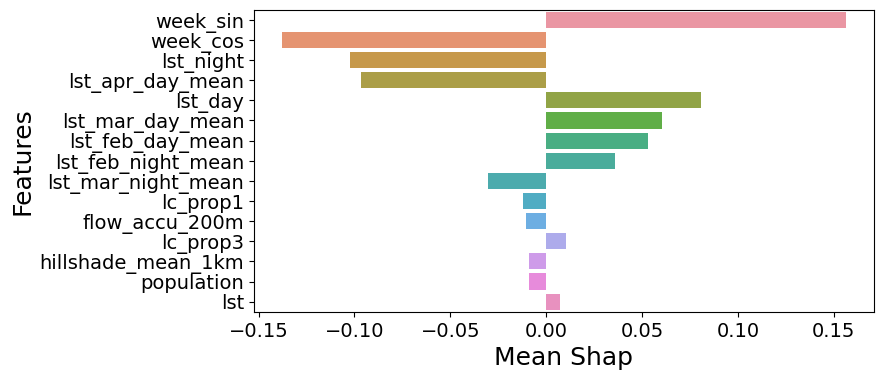

In [23]:
mean_shap = shap_values.mean(axis=0)
mean_shap = mean_shap.reshape(1,mean_shap.shape[0])

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

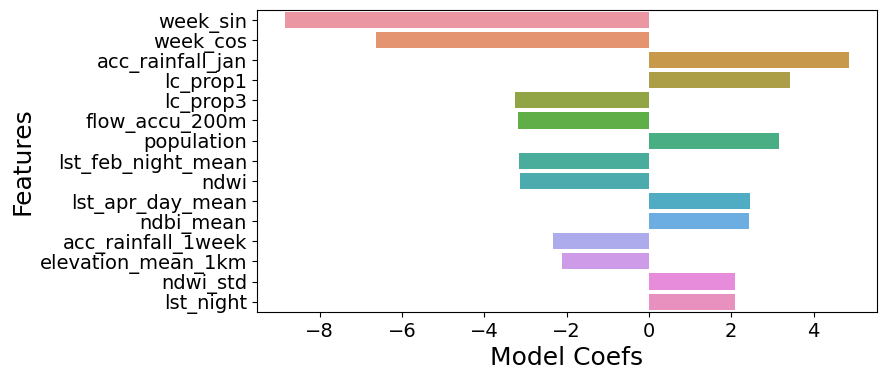

In [16]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

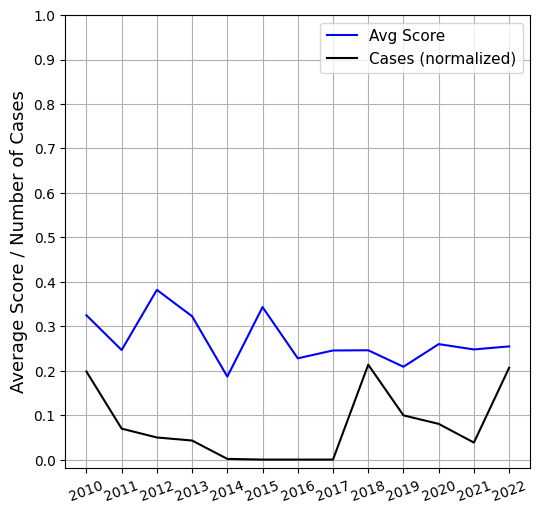

In [17]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

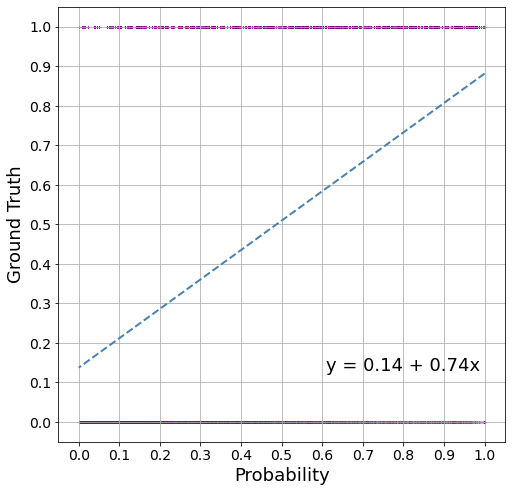

(0.13758713916756893, 0.7437680464746778)

In [18]:
plot_probability_curve(results_test)

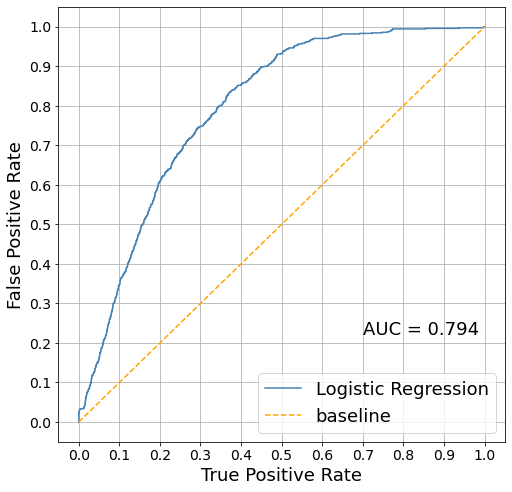

(0.2929, 0.7444, 0.3779, 0.7255)

In [19]:
plot_roc_curve(results_test)

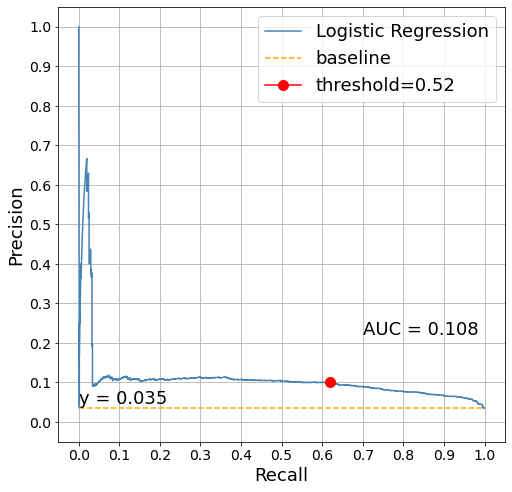

(0.6201, 0.1, 0.52, 0.3028)

In [20]:
plot_pr_curve(results_test, plot_fbeta = True)

In [21]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 20.30%
Weighted Average: 29.07%

Random Average: 9.22%
Random Weighted Average: 11.72%
